In [1]:
!pip install opencv-python numpy matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
image = cv2.imread("darkwithbkurmoon.jpg")

In [4]:
print(image.dtype)

uint8


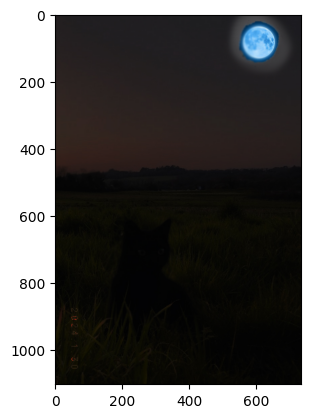

In [29]:
plt.imshow(image)

In [6]:
print(image)
#Blue
# Green
# Red

[[[32 31 35]
  [32 31 35]
  [32 31 35]
  ...
  [32 27 28]
  [32 27 28]
  [32 27 28]]

 [[32 31 35]
  [32 31 35]
  [32 31 35]
  ...
  [32 27 28]
  [32 27 28]
  [32 27 28]]

 [[32 31 35]
  [32 31 35]
  [32 31 35]
  ...
  [33 28 29]
  [33 28 29]
  [33 28 29]]

 ...

 [[13 15 16]
  [ 7 11 12]
  [ 2  5  9]
  ...
  [ 3  5  6]
  [ 4  6  7]
  [ 4  6  7]]

 [[11 13 14]
  [ 3  7  8]
  [ 0  2  6]
  ...
  [ 3  5  5]
  [ 3  5  5]
  [ 4  6  6]]

 [[ 7 11 12]
  [ 2  6  7]
  [ 0  4  7]
  ...
  [ 4  6  6]
  [ 3  5  5]
  [ 3  5  5]]]


In [7]:
print(image.shape)
#(height , width , channels color)

(1103, 735, 3)


In [8]:
print(image.dtype)

uint8


In [9]:
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

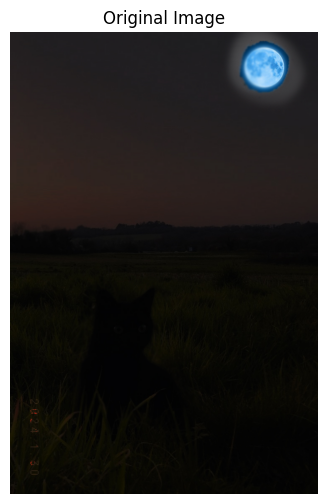

In [10]:
plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

In [11]:
output_linear = cv2.convertScaleAbs(image, alpha=1.3, beta=40)

In [12]:
gamma = 0.4

lookuptable = np.empty((1,256), np.uint8)

for i in range(256):
    lookuptable[0,i] = np.clip(pow(i/255,gamma)*255,0,255)

output_gamma = cv2.LUT(image,lookuptable)

In [13]:
print(image.dtype)
print(image.shape)
print(lookuptable.dtype)

uint8
(1103, 735, 3)
uint8


In [14]:
print(image.dtype)

uint8


(np.float64(-0.5), np.float64(734.5), np.float64(1102.5), np.float64(-0.5))

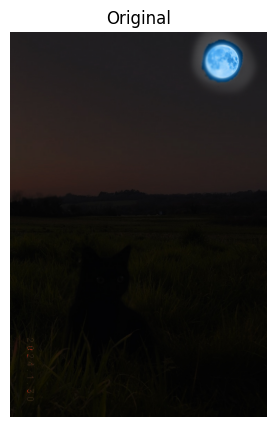

In [15]:
plt.figure(figsize=(15,5))
plt.subplot(131)
plt.imshow(image)
plt.title("Original")
plt.axis("off")


(np.float64(-0.5), np.float64(734.5), np.float64(1102.5), np.float64(-0.5))

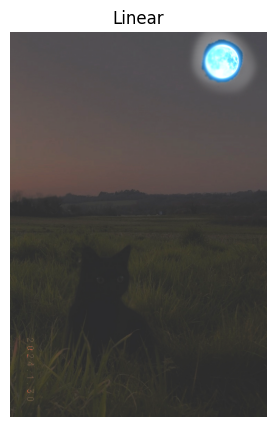

In [16]:
plt.figure(figsize=(15,5))
plt.subplot(132)
plt.imshow(output_linear)
plt.title("Linear")
plt.axis("off")

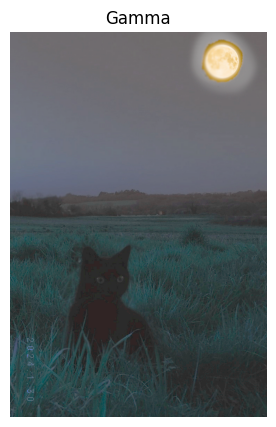

In [19]:
plt.figure(figsize=(15,5))
plt.subplot(133)
plt.imshow(output_gamma[...,::-1])
plt.title("Gamma")
plt.axis("off")

plt.show()

In [18]:
print(image.dtype)
print(image.shape)
print(image.min())
print(image.max())

uint8
(1103, 735, 3)
0
255


In [20]:
output_linear = cv2.convertScaleAbs(
    image,
    alpha=1.5,
    beta=50
)

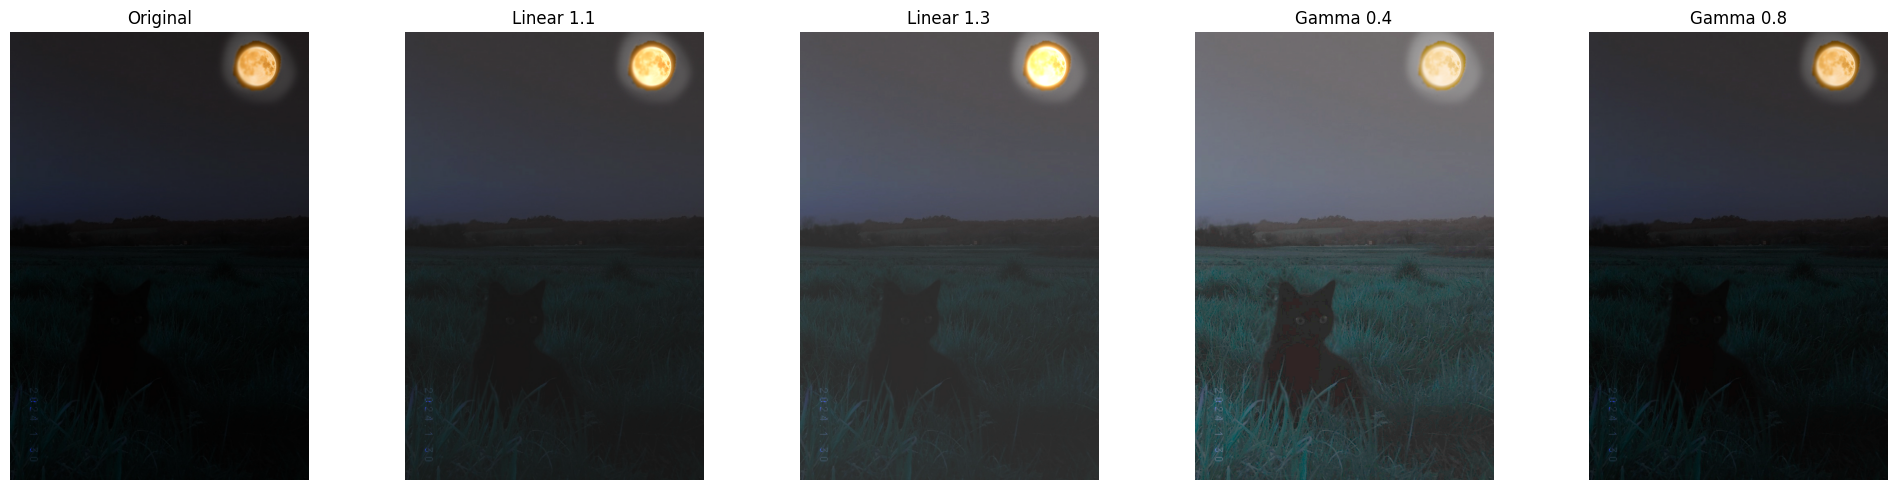

In [25]:
linear1 = cv2.convertScaleAbs(image, alpha=1.1, beta=20)
linear2 = cv2.convertScaleAbs(image, alpha=1.3, beta=40)

# Gamma 0.4
gamma = 0.4
lookuptable = np.empty((1,256),np.uint8)

for i in range(256):
    lookuptable[0,i]=np.clip(pow(i/255,gamma)*255,0,255)

gamma04 = cv2.LUT(image,lookuptable)

# Gamma 0.8
gamma = 0.8
lookuptable = np.empty((1,256),np.uint8)

for i in range(256):
    lookuptable[0,i]=np.clip(pow(i/255,gamma)*255,0,255)

gamma08 = cv2.LUT(image,lookuptable)

plt.figure(figsize=(20,5))

images=[image,linear1,linear2,gamma04,gamma08]
titles=["Original","Linear 1.1","Linear 1.3","Gamma 0.4","Gamma 0.8"]

for i in range(5):

    plt.subplot(1,5,i+1)
    plt.imshow(images[i][...,::-1])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

"""so the best of gamma is 0.4 with me edited picture in photoshop with blur and brightness is -140x2
and linear the best is 1.3 i guess
next is the chatgpt edited pictures for test linear is better or gamma?"""

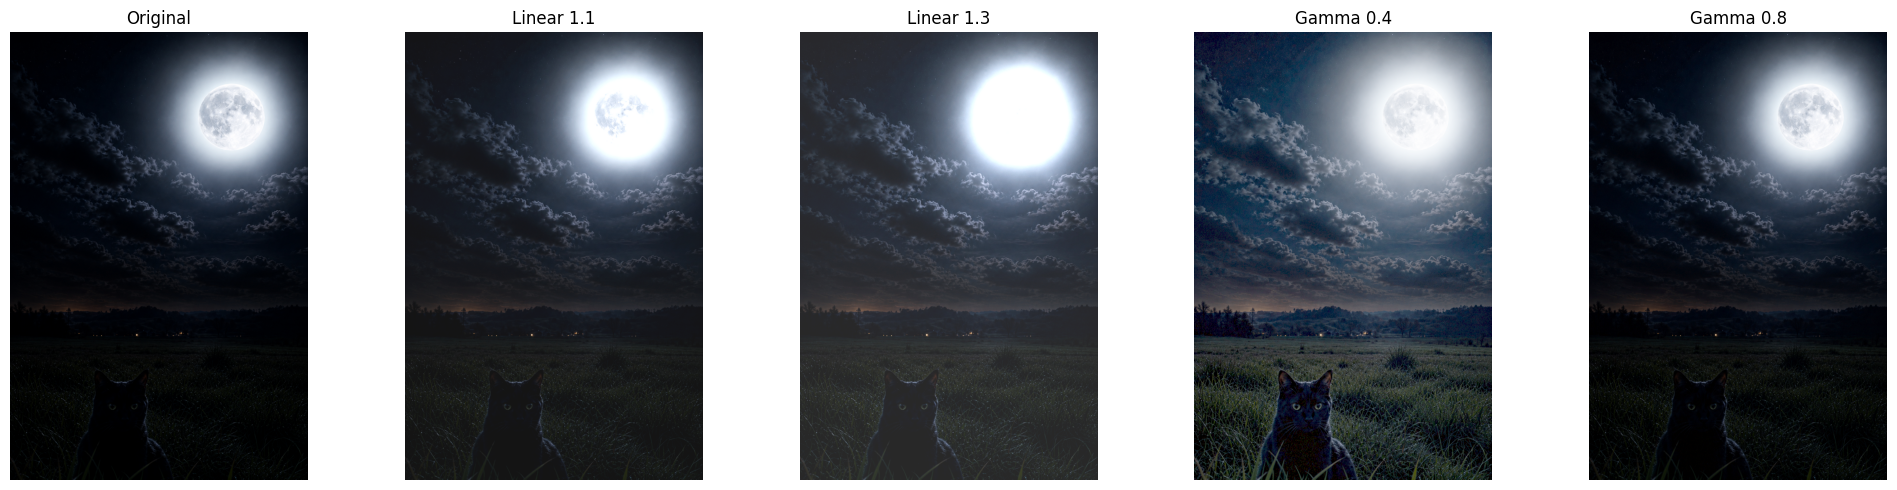

In [28]:
#chatgpt image with more blur and shinier moon
img2=cv2.imread("chatgpteditedimg.png")

linear1 = cv2.convertScaleAbs(img2, alpha=1.1, beta=20)
linear2 = cv2.convertScaleAbs(img2, alpha=1.3, beta=40)

# Gamma 0.4
gamma = 0.4
lookuptable = np.empty((1,256),np.uint8)

for i in range(256):
    lookuptable[0,i]=np.clip(pow(i/255,gamma)*255,0,255)

gamma04 = cv2.LUT(img2,lookuptable)

# Gamma 0.8
gamma = 0.8
lookuptable = np.empty((1,256),np.uint8)

for i in range(256):
    lookuptable[0,i]=np.clip(pow(i/255,gamma)*255,0,255)

gamma08 = cv2.LUT(img2,lookuptable)

plt.figure(figsize=(20,5))

images=[img2,linear1,linear2,gamma04,gamma08]
titles=["Original","Linear 1.1","Linear 1.3","Gamma 0.4","Gamma 0.8"]

for i in range(5):

    plt.subplot(1,5,i+1)
    plt.imshow(images[i][...,::-1])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

"""so linear 1.3 is soo much shine
and the best is gamma 0.4"""